# Assessing the behavior of an internal control of an assay

Have you ever taken a COVID-19 test before? Maybe you've had to give a blood sample at the doctor's office? Now that you are thinking of these things, have you ever wondered more about how these tests work? These 'tests' are known as assays and there are many types of assays on the market -- ranging from PCR for molecular biology, to color-changing tests for chemistry, to clotting tests for genetic markers in your blood. 

This data is from a project I wanted to complete for my job: 

* We were developing a test in which you (the user) would swirl your nostril with a swab and then swirl the swab in a cup. 

* You would then close the cup and put it in our instrument, press go on the associated app, and a test would run.

* The results of this test would then tell you directly if it detected Flu, RSV, or Covid!


**In order to know if the test itself was working correctly (i.e., there were no malfunctioning chemical components) and to ensure the best product for consumers, an internal control within the cup also is assessed to confirm all chemistry within the cup is working accurately. **

## But how do we know we can trust the internal control?

In this notebook, we will go through the data together and show that the internal control recieved from manufacturing is functioning as it should. Specifically, this data set looks at three things: 
* The **Tm** (or the melting temperature reported by the instrument) -- The control should melt at a specific temperature which confirms the correct biological product is present
* The **Peak Height** (or the fluorescent peak reported by the instrument) -- The control should peak at a specific range which confirms the fluorescent tag on the biological product is present
* The **Tm** and the **Peak Height** over time -- The control should be staying at the same relative Tm and Peak Height over a range of time

## Upload and clean the data

In [1]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
IC_data = pd.read_excel('Control_Monitoring_Charts_EC.xlsx')
IC_data.head()

,CONSUMABLE ID,lot,inst_name,analysisVersion,Tm,Peak Height,firmwareVersion,protocolName
0,05ebd8c5-1a01-0208-01c0-1c8868e96f13,TKM-6303,1101,1.3.6,87.445,10.324,1.8.4,MVRK-SCT-1003
1,914073ce-1a01-0208-01c0-1c8868e96eed,TKM-6303,1146,1.3.6,89.316,4.4811,1.8.4,MVRK-SCT-1003
2,d32dfdab-1a01-0208-01c0-1c8868e9729d,TKM-6303,1160,1.3.6,88.433,17.421,1.8.4,MVRK-SCT-1003
3,a3cf09f6-1a01-0208-01c0-1c8868e96e7f,TKM-6303,1143,1.3.6,88.183,8.3651,1.8.4,MVRK-SCT-1003
4,d69f36fe-1a01-0208-01c0-1c8868e96ea8,TKM-6303,1113,1.3.6,88.13,19.224,1.8.4,MVRK-SCT-1003


At first glance, this data seems clean. However, I know multiple values can be contained in the columns Tm and Peak Height. I also want to standardize the way the columns are named to Camel Case. 

In [3]:
IC_data.rename(columns={'CONSUMABLE ID':'consumableID', 'lot':'lotNum', 'inst_name':'instName', 'Peak Height':'peakHeight'}, inplace = True)
IC_data.head()

,consumableID,lotNum,instName,analysisVersion,Tm,peakHeight,firmwareVersion,protocolName
0,05ebd8c5-1a01-0208-01c0-1c8868e96f13,TKM-6303,1101,1.3.6,87.445,10.324,1.8.4,MVRK-SCT-1003
1,914073ce-1a01-0208-01c0-1c8868e96eed,TKM-6303,1146,1.3.6,89.316,4.4811,1.8.4,MVRK-SCT-1003
2,d32dfdab-1a01-0208-01c0-1c8868e9729d,TKM-6303,1160,1.3.6,88.433,17.421,1.8.4,MVRK-SCT-1003
3,a3cf09f6-1a01-0208-01c0-1c8868e96e7f,TKM-6303,1143,1.3.6,88.183,8.3651,1.8.4,MVRK-SCT-1003
4,d69f36fe-1a01-0208-01c0-1c8868e96ea8,TKM-6303,1113,1.3.6,88.13,19.224,1.8.4,MVRK-SCT-1003


I will remove NaN's since we want to visualize data that exists. Prior knowledge of this set means I know we can remove these NaN's safely

In [4]:
# drop NaNs
IC_data = IC_data.dropna()

# confirm if NaNs exist
IC_data.isna().any()

consumableID       False
lotNum             False
instName           False
analysisVersion    False
Tm                 False
peakHeight         False
firmwareVersion    False
protocolName       False
dtype: bool

Next, I will split any multiple values into two columns -- I know that **if** there are multiple values, the first value is one analyte, while the second one is the control I want to monitor. 

In [5]:
# now parse columns - this will split either into the 
# analyte + the Internal Control
# OR 
# it will fill the single value (that is the internal control)
# to the internal control column if a '|' does not exist

split_tm = IC_data['Tm'].astype(str).str.split('|', expand = True)
IC_data['a1_Tm'] = split_tm[0].astype(float)
IC_data['icTm'] = split_tm[1].fillna(split_tm[0]).astype(float)

split_peak = IC_data['peakHeight'].astype(str).str.split('|', expand = True)
IC_data['a1_peak'] = split_peak[0].astype(float)
IC_data['icPeak'] = split_peak[1].fillna(split_peak[0]).astype(float)

# confirm delimiter split columns in question into multiple columns
IC_data.iloc[23:26].head()

,consumableID,lotNum,instName,analysisVersion,Tm,peakHeight,firmwareVersion,protocolName,a1_Tm,icTm,a1_peak,icPeak
24,51eb65b1-1a01-0208-01c0-1c8868e96b00,TKM-6303,1315,1.3.6,82.941|88.12,10.538|32.305,1.8.4,MVRK-SCT-1003,82.941,88.120,10.538,32.305
25,db360f88-1a01-0208-01c0-1c8868e97823,TKM-6303,1306,1.3.6,82.369|87.544,17.11|71.15,1.8.4,MVRK-SCT-1003,82.369,87.544,17.110,71.150
26,3f0697fc-1a01-0208-01c0-1c8868e976ff,TKM-6303,1301,1.3.6,82.749|88.521,12.243|55.08,1.8.4,MVRK-SCT-1003,82.749,88.521,12.243,55.080


Now, let's reorder the table so the columns in use are at the front of the table

In [6]:
IC_data = IC_data[['consumableID', 'lotNum', 'instName', 'analysisVersion', 'firmwareVersion', 'protocolName', 'icTm', 'icPeak']]
IC_data.head()

,consumableID,lotNum,instName,analysisVersion,firmwareVersion,protocolName,icTm,icPeak
0,05ebd8c5-1a01-0208-01c0-1c8868e96f13,TKM-6303,1101,1.3.6,1.8.4,MVRK-SCT-1003,87.445,10.3240
1,914073ce-1a01-0208-01c0-1c8868e96eed,TKM-6303,1146,1.3.6,1.8.4,MVRK-SCT-1003,89.316,4.4811
2,d32dfdab-1a01-0208-01c0-1c8868e9729d,TKM-6303,1160,1.3.6,1.8.4,MVRK-SCT-1003,88.433,17.4210
3,a3cf09f6-1a01-0208-01c0-1c8868e96e7f,TKM-6303,1143,1.3.6,1.8.4,MVRK-SCT-1003,88.183,8.3651
4,d69f36fe-1a01-0208-01c0-1c8868e96ea8,TKM-6303,1113,1.3.6,1.8.4,MVRK-SCT-1003,88.130,19.2240


## Visualize cleaned data

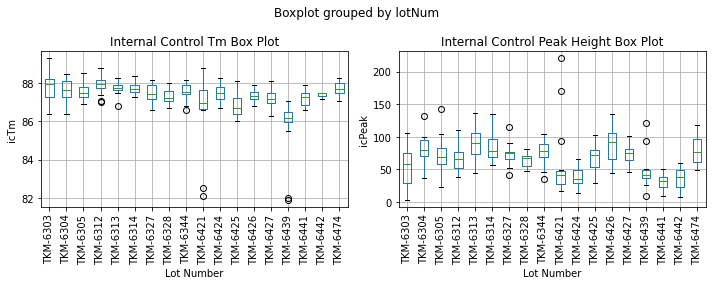

In [7]:
# plot Tm and Peak Heights side by side for ease of viewing
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

IC_data.boxplot(column='icTm', by = 'lotNum', ax=ax1)
IC_data.boxplot(column='icPeak', by = 'lotNum', ax=ax2)

# format
ax1.set_title('Internal Control Tm Box Plot')
ax1.set_ylabel('icTm')
ax1.set_xlabel('Lot Number')
ax1.tick_params(axis = 'x', labelrotation=90)

ax2.set_title('Internal Control Peak Height Box Plot')
ax2.set_ylabel('icPeak')
ax2.set_xlabel('Lot Number')
ax2.tick_params(axis = 'x', labelrotation=90)

# show plot
plt.tight_layout()
plt.show()

**From the above plots, we can see that peak heights are quite variable - but more so in some material lots than others. Specifically: this piques my interest to keep an eye on Lot 6421 and 6439 as they have the most eye-catching outliers in both graphs.**

This also shows that some materials in these lots may be quite variable as well, since I know peak heights are directly impacted by the enzyme within the chemistry. 

It is good to see that the melting temperature (Tm) is less variable, and that when it is variable it is a noticeable outlier per lot. These specific points should be further investigated by the R&D team to check if it was instrument related or experiment related

We do not have dates for each consumable run, but each lot is chronological -- therefore we can plot lot number as a substitute for time

**Let's visualize with a psuedo-time-series plot the overall behavior of the control over time**


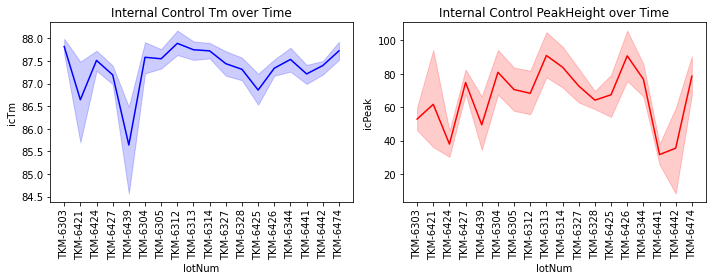

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(data=IC_data, x = 'lotNum', y = 'icTm', color='blue', ax=axes[0])
axes[0].set_title("Internal Control Tm over Time")
sns.lineplot(data=IC_data, x = 'lotNum', y = 'icPeak', color='red', ax=axes[1])
axes[1].set_title("Internal Control PeakHeight over Time")
axes[0].tick_params(axis = 'x', labelrotation=90)
axes[1].tick_params(axis = 'x', labelrotation=90)


plt.tight_layout()
plt.show()

The shading on the graphs above represent the Confidence Interval (95%). The dark line represents the average value of the data points. When the shaded region is wide, it indicates high variability.

**This data shows there are lots with high variability of melting temperature AND peak heights especially in lots 6421 and 6439. The PCR data from these lots should be highly scrutinized** The Tm over time is certainly easier to assess in this manner and these conclusions are mainly derived from this chart. 

As for variability over time (using lot number as a substitute), there are small periods of time where the reproducibility of the control is consistent. **This poor reproducibility should be improved with a better manufacturing process. This was a known issue within the company. **

To finalize this conclusion, a [CUSUM chart](https://sixsigmastudyguide.com/cumulative-sum-chart-cusum/) (Cumulative Sum Control Chart) would be a good visualization. To do this, we must know a general baseline of the data -- see the math below:

*The y-axis in these charts will be the cumulative sum of the deviations of the data points*

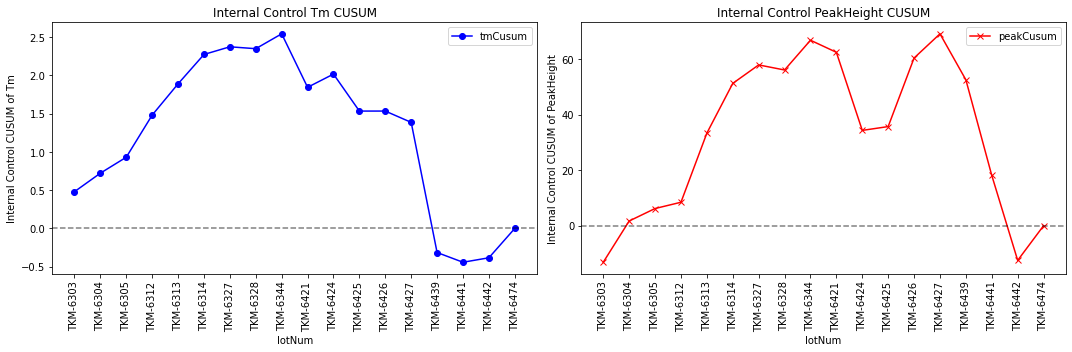

In [9]:
#calculate the average of each metric grouped by lot
lot_data = IC_data.groupby('lotNum')[['icTm', 'icPeak']].mean().reset_index()
tm_target = lot_data['icTm'].mean()
peak_target = lot_data['icPeak'].mean()

#calculate the deviation from the average
lot_data['tmDeviation'] = lot_data['icTm'] - tm_target
lot_data['peakDeviation'] = lot_data['icPeak'] - peak_target

#calculate the cumulative sum of the deviation away from the average
lot_data['tmCusum'] = lot_data['tmDeviation'].cumsum()
lot_data['peakCusum'] = lot_data['peakDeviation'].cumsum()

#plot
fig, axes = plt.subplots(1,2, figsize=(15, 5))
lot_data.plot(x='lotNum', y='tmCusum', ax=axes[0], marker='o', title='Internal Control Tm CUSUM', color='blue')
axes[0].set_ylabel('Internal Control CUSUM of Tm')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)

lot_data.plot(x='lotNum', y='peakCusum', ax=axes[1], marker='x', title='Internal Control PeakHeight CUSUM', color='red')
axes[1].set_ylabel('Internal Control CUSUM of PeakHeight')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

axes[0].set_xticks(range(len(lot_data['lotNum'])))
axes[0].set_xticklabels(lot_data['lotNum'], rotation=90)
axes[1].set_xticks(range(len(lot_data['lotNum'])))
axes[1].set_xticklabels(lot_data['lotNum'], rotation=90)
plt.tight_layout()

The charts above show a few things:
* First, between lots 6304 and 6314, there was an increasing deviation in manufacturing
* Then, there was a subsequent loss in deviation from lots 6344 to 6439 (specifically in Tm)
* **The manufacturing process was known to need optimization in order for reproducibility, but there should also be a new standardization of the control and all other materials in manufacturing**

Furthermore: A melting shift of 1 degree +/- was seen regularly. A shift of 2 - 3 degrees +/- is definitely more concerning. The way the chemistry of melting temperature works is very specific, and a shift in temperature often signifies that there is a different biological product or some other issue at play. 

Peak heights are fluorescent signal which are impacted by several factors: the sensor and instrument could be out of calibration, the fluorescent molecule itself could be more or less concentrated than normal, or something like the actual assay's PCR ingredients could affect the way the fluorophore becomes available to fluoresce. For these reasons, the signal is acceptable to be more variable and standardized by the algorithm behind the scenes to adjust for these factors. All that being said: a change in 20 units of fluorescence is somewhat acceptable while a change in more than that is highly suspect.  

These charts show the cumulative sum of change, but now you may also understand what type of changes are acceptable versus unacceptable. 

## K-means to represent if a lot or instrument in particular are affecting these metrics the most

Below, K-means will establish groupings based on two features of interest (icTm and icPeak). 

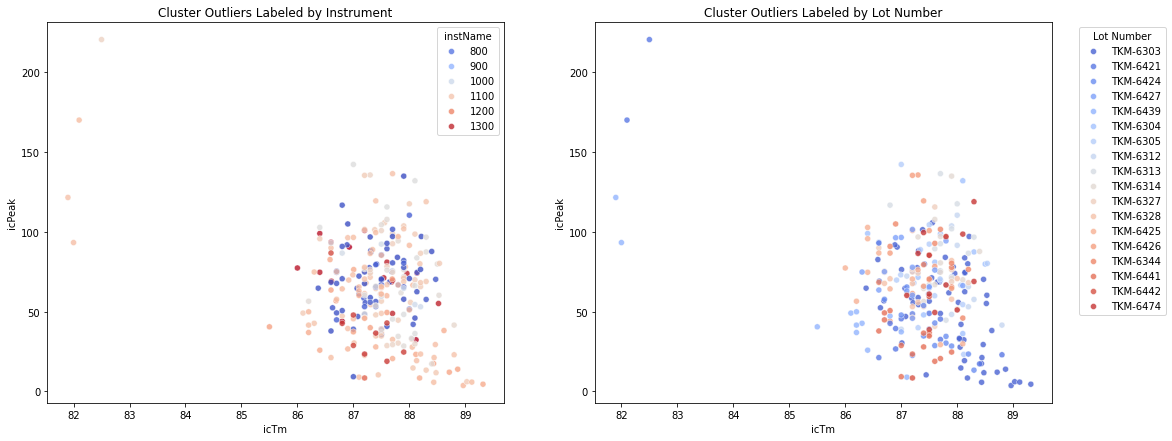

In [10]:
# select features of interest
features = ['icTm', 'icPeak']
X = IC_data[features]

# scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2 clusters to define as "normal" vs "abnormal", with a seed, and number of times to run k-means
kmeans = KMeans(n_clusters=2, random_state=6040, n_init=10)
IC_data['Cluster'] = kmeans.fit_predict(X_scaled)

# plot the results of k-means clustering
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
outliers = IC_data[IC_data['Cluster'] == 1]

sns.scatterplot(data=IC_data, x='icTm', y='icPeak', hue='instName', palette='coolwarm', ax=axes[0], alpha=0.8)
axes[0].set_title('Cluster Outliers Labeled by Instrument')

sns.scatterplot(data=IC_data, x='icTm', y='icPeak', hue='lotNum', palette='coolwarm', ax=axes[1], alpha=0.8)
axes[1].set_title('Cluster Outliers Labeled by Lot Number')
axes[1].legend(title='Lot Number', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Here, we can see that there are a few data points that fall into an 'outlier' type of cluster. Specifically: it appears one instrument is consistently an outlier, and there are two lots that are also outliers. It is hard to say whether the instrument is the true culprit as it seems more likely that it is Lot dependent.

To further understand what specific lot or instrument these are, see the cell below:
* Crosstab (or cross-tablulation) is a statistical method used to analyze the relationship between two categorical variables -- this is a built-in tool found in Pandas. 
* I will make two grids: one that shows how many points in cluster 1 are from a specific instrument, and another that shows the same analysis but for lot number



In [14]:
# for summary statistics:
summary_data = {
    'Metric': ['Total Runs (Rows)', 'Total Unique Lots', 'Total Unique Instruments'],
    'Count': [
        len(IC_data), 
        IC_data['lotNum'].nunique(), 
        IC_data['instName'].nunique()
    ]
}


summary_table = pd.DataFrame(summary_data)


# create the crosstab with total runs -- for instruments
inst_summary = pd.crosstab(IC_data['instName'], IC_data['Cluster'], margins=True, margins_name='Total Runs')
final_grid = inst_summary[[1, 'Total Runs']].drop('Total Runs', axis=0)
final_grid.columns = ['Runs in Cluster 1', 'Total Runs']

# only show rows where the count in Cluster 1 is greater than 0
cluster1 = final_grid[final_grid['Runs in Cluster 1'] > 0]

# display sorted by the number of 'failures'
print("Instruments Involved in Abnormal Cluster:")
print(cluster1.sort_values(by='Runs in Cluster 1', ascending=False))

print('\n---------------------------------------------\n')

# create crosstab with total runs -- for lots
lot_summary = pd.crosstab(IC_data['lotNum'], IC_data['Cluster'], margins=True, margins_name='Total Appearance of Lot')
final_grid_lot = lot_summary[[1, 'Total Appearance of Lot']].drop('Total Appearance of Lot', axis=0)
final_grid_lot.columns = ['Lots in Cluster 1', 'Total Appearance of Lot']
cluster1_lot = final_grid_lot[final_grid_lot['Lots in Cluster 1'] > 0]
print("Lot Numbers Involved in Abnormal Cluster:")
print(cluster1_lot.sort_values(by='Lots in Cluster 1', ascending=False))

print('\n---------------------------------------------\n')
print('Summary Table')
summary_table

Instruments Involved in Abnormal Cluster:
          Runs in Cluster 1  Total Runs
instName                               
1069                      1           1
1109                      1           5
1113                      1           6
1118                      1           2

---------------------------------------------

Lot Numbers Involved in Abnormal Cluster:
          Lots in Cluster 1  Total Appearance of Lot
lotNum                                              
TKM-6421                  2                       14
TKM-6439                  2                       12

---------------------------------------------

Summary Table


,Metric,Count
0,Total Runs (Rows),273
1,Total Unique Lots,18
2,Total Unique Instruments,99


Looking at the actual number of each suspect lot or instrument within the abnormal cluster is not very compelling. I firmly believe the issue with reproducibility must be a combination of factors: perhpas both material lots and the need of calibration of the instrument

## Heatmap of average Tm values across lot and instrument: An extra analysis suggested in my research

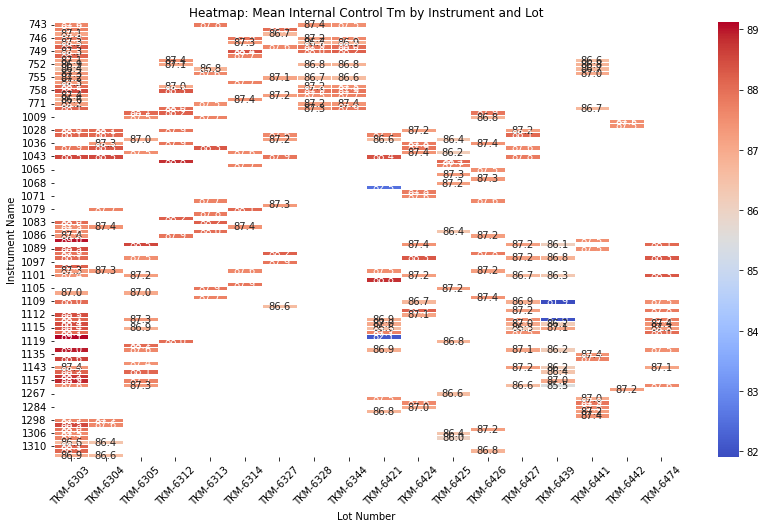

In [12]:
# pivot table created where rows are instruments, columns are lots and values are average metric

heatmap_data = IC_data.pivot_table(
    index='instName', 
    columns='lotNum', 
    values='icTm', 
    aggfunc='mean'
)

# plot
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True,      # print Tm on calls as annotations
    fmt=".1f",       # round to 1 decimal place
    cmap='coolwarm', # blue for low Tm, red for high Tm
    linewidths=.5
)

plt.title('Heatmap: Mean Internal Control Tm by Instrument and Lot')
plt.xlabel('Lot Number')
plt.ylabel('Instrument Name')
plt.xticks(rotation=45)
plt.show()

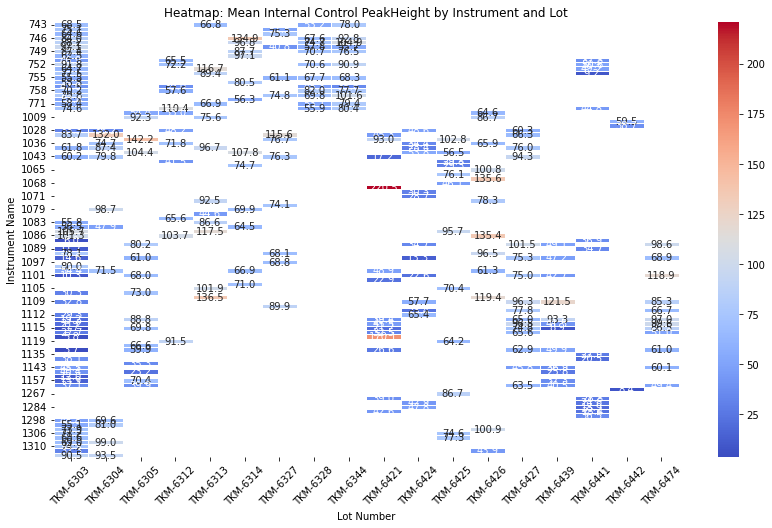

In [13]:
# pivot table created where rows are instruments, columns are lots and values are average metric

heatmap_data = IC_data.pivot_table(
    index='instName', 
    columns='lotNum', 
    values='icPeak', 
    aggfunc='mean'
)

# plot
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,      # print peak heights on cells as annotations
    fmt=".1f",       # round to 1 decimal place
    cmap='coolwarm', # blue for low peak, red for high peak
    linewidths=.5
)

plt.title('Heatmap: Mean Internal Control PeakHeight by Instrument and Lot')
plt.xlabel('Lot Number')
plt.ylabel('Instrument Name')
plt.xticks(rotation=45)
plt.show()

## Conclusion

This project idea was something I wanted to do for my job as an R&D scientist - which is how I have deep understanding of the potential issues with this data or its outcomes. This is an important thing to note, as often this is a gap in knowledge for the data scientists in our group who perform these analysis for us on an occasional basis. My passion for learning data science comes from knowing this gap exists, and that bridging this gap could have a large improvement on patients lives directly.

This analysis only concerns an internal control which ensures a good product, but I know this could be largely applied to a vast field in medical devices, healthcare, and efficient and effective diagnoses for patients. 

From this analysis, of which there was prior knowledge of faulty manufacturing processes, a lack of instrument calibration, and known reproducibility issues, we now know:
* **The instruments themselves do not seem to be a direct cause by itself of poor reproducibility of the internal control**
* **The lot of each consumable material is more suspect than instruments in causing poor reproducibility of the internal control**
* **K-means clustering shows the above two points - that there are definite outliers, and it could be due to combined factors**
* **The heatmap shows that it is not one specific lot or one specific instrument that is cause for poor reproducibility**
* **Poor reproducibility exists as seen by the CUSUM charts and the Confidence Interval bands over time**

From the data I have on hand, it is hard to know what is exactly the problem. However, this analysis has its benefits:
* Without understanding these nuances, the R&D group had to detour from our development of the product and explore these inconsistencies
* Had these analyses been available from the beginning, time and money would have been saved along the way
* Now we can advise the manufacturing and engineering departments, as well as the head of operations, more concisely what needs to be changed to improve processes. 